# Reto Spaceship Titanic - Avance 1

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 31 de agosto de 2026 |

---

## 1. Carga y comprensión del dataset

### 1.1 Carga de `train.csv` y `test.csv`

Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle. No se realiza split adicional: todo el trabajo de preparación se desarrolla sobre `train.csv`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

import math

In [2]:
train = pd.read_csv('../data/titanic_data/train.csv')
test = pd.read_csv('../data/titanic_data/test.csv')

### 1.2 Inspección de estructura: shape, tipos de variables y primeras filas

Revisión del número de filas y columnas, tipos de datos (`dtypes`) por variable, y muestra de las primeras observaciones (`head`) para comprender el formato general del dataset.

In [3]:
print(test.shape)
print(train.shape)

(4277, 13)
(8693, 14)


In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [6]:
train.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

### 1.3 Identificación de la variable target y tipo de problema

`Transported` es nuestra variable objetivo. El problema que se está intentando resolver en este escenario es identificar a los pasajeros que fueron transportados a la dimensión alterna, por lo que cuadra perfectamente con el dato booleano que aparece en el training set. 

El tipo de problema al que nos enfrentamos es una **clasificación binaria supervisada**, ya que la predicción solo puede caer en dos categorías, y además tenemos acceso a una muestra con valores predefinidos de True/False para `Transported` (test.csv). A partir de esto podemos verificar algunas de las respuestas que da el modelo y proporcionarle retroalimentación.

## 2. Análisis exploratorio (EDA)

### 2.1 Valores faltantes: porcentaje por columna y clasificación (informativo vs. real)

Cálculo del porcentaje de faltantes por columna. Cada variable se clasifica como **faltante informativo** o **faltante real**, justificando cada clasificación con el contexto del dataset descrito en Kaggle.

In [7]:
faltantes = train.isnull().sum()
faltantes / len(train) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

**Check extra:** confirmar la hipótesis acerca del CryoSleep. Los pasajeros no deberían de gastar si están en este estado

In [8]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
total_spend = train[spend_cols].sum(axis=1, skipna=True)
check = train.loc[train["CryoSleep"].notna() & (total_spend > 0), "CryoSleep"]
print((check == True).sum(), "de", len(check))
print(check.value_counts(dropna=False))

0 de 4921
CryoSleep
False    4921
Name: count, dtype: int64


**Tabla de clasificación de variables**

| Variable | Faltante | Justificación |
|---|---|---|
| CryoSleep | Faltante real  | Un pasajero dormido no puede consumir. Si el gasto es > 0, CryoSleep debe ser false. Entonces los casos faltantes, son un hueco. |
| ShoppingMall |Faltante informativo  | Siguiendo con el razonamiento anterior, si CyroSleep es true, ShoppingMall debe ser 0. Entonces el pasajero no gastó nada. Si CryoSleep es False o desconocido, es un faltante real que requiere imputación estadística (mediana condicionada a pasajeros despiertos).  |
| VIP | Faltante real  | No hay motivo lógico por el que la ausencia signifique algo sistinto a "no se capturó". |
| HomePlanet | Faltante real | Su ausencia es porque no se capturó. Puede ser posible recuperarla por relaciones de miembros del mosmo grupo, deck o cabin |
| Name | Faltante real | No es relevante. Su ausencia no aporta nada al target, además es un identificador casi único. |
| Cabin | Faltante real | Si falta, no afecta al target, puede ser una falta de captura y no necesariamente que el pasajero no tenga cabina. |
| VRDeck | Faltante informativo | Igual que ShoppingMall, si CryoSleep es true, tiene que ser 0. Se tendría que comprobar que el pasajero está o estuvo activo para imputar el faltante. |
| Spa | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| FoodCourt | Faltante informativo  | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Destination | Faltante real | La ausencia es porque no se capturó, sin embargo el destino no aporta nada al target porque los pasajeros no son acomodados necesariamente por destino. |
| RoomService | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Age | Faltante real | Al igual que el nombre, no hay razón por la que "sin edad" signifique algo. No tiene relación determinística con otras variables. |

### 2.2 Variables numéricas: distribución, skewness y outliers

Histogramas de las variables numéricas, cálculo de asimetría (skewness) y detección de outliers mediante el método de Tukey/rango intercuartílico (IQR).

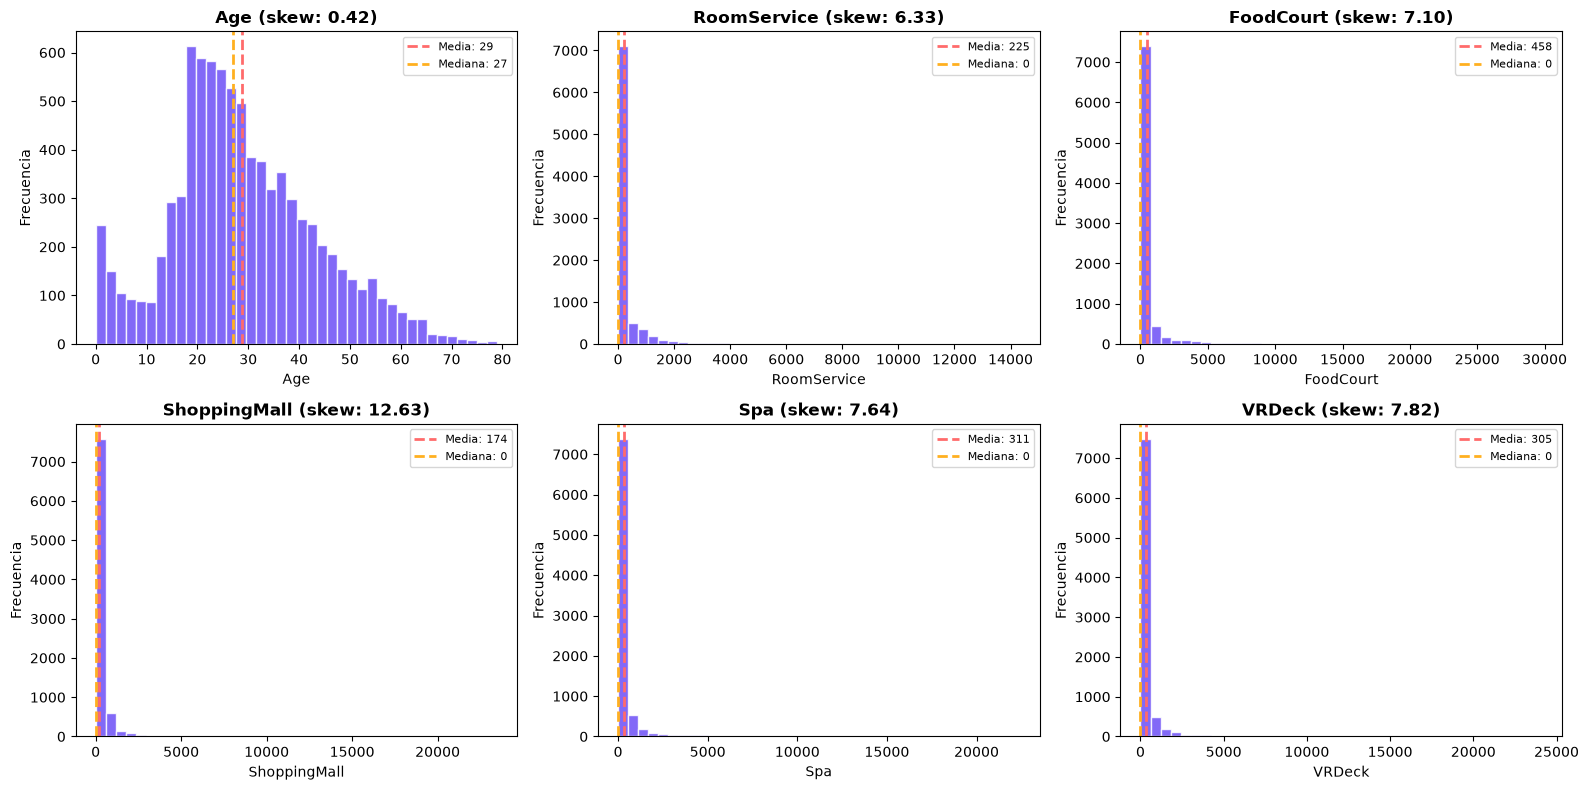

In [9]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cols):
    ax.hist(train[col].dropna(), bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
    ax.axvline(train[col].mean(), color='#FF6B6B', linewidth=2,
               linestyle='--', label=f"Media: {train[col].mean():,.0f}")
    ax.axvline(train[col].median(), color='#FFB020', linewidth=2,
               linestyle='--', label=f"Mediana: {train[col].median():,.0f}")

    ax.set_title(f"{col} (skew: {train[col].skew():.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [10]:
info_outliers = []

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lim_inf) | (train[col] > lim_sup)]

    info_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': lim_inf,
        'Límite superior': lim_sup,
        'Num outliers': len(outliers),
        'Porcentaje outliers': len(outliers) / len(train) * 100
    })

outliers_df = pd.DataFrame(info_outliers)

outliers_df

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Num outliers,Porcentaje outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.885770
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.408029
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,20.970896
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.039917
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,20.568273
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,20.809847


### 2.3 Variables categóricas: cardinalidad, distribución y desbalance

Análisis de la cardinalidad de cada variable categórica, distribución de sus categorías y detección de variables con desbalance extremo entre clases.

In [ ]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']

""" for col in v_categoricas:
    print(f"Valores en {col}:")
    print(train[col].value_counts())
 """

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

Cabin          6560
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

Cabin tiene una cardinalidad demasiado alta, pero es una variable compuesta. Podemos separar Deck, Side y NumCabin para analizar si alguna de estas variables tiene una cardinalidad más baja y que pueda ser de verdadera utilidad para el modelo.

In [12]:
train[['Deck', 'NumCabin', 'Side']] = train['Cabin'].str.split('/', expand=True)
train['NumCabin'] = pd.to_numeric(train['NumCabin'])

test[['Deck', 'NumCabin', 'Side']] = test['Cabin'].str.split('/', expand=True)
test['NumCabin'] = pd.to_numeric(test['NumCabin'])

Comprobamos la cardinalidad otra vez con las nuevas columnas:

In [14]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'NumCabin', 'Deck', 'Side']

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

NumCabin       1817
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
Side              2
dtype: int64

### 2.4 Relación de cada variable con el target

Crosstabs entre variables categóricas y `Transported`, y boxplots de variables numéricas segmentados por `Transported`. Este análisis es la base para justificar qué variables entran y cuáles se descartan en la siguiente etapa. Se excluye NumCabin por cardinalidad

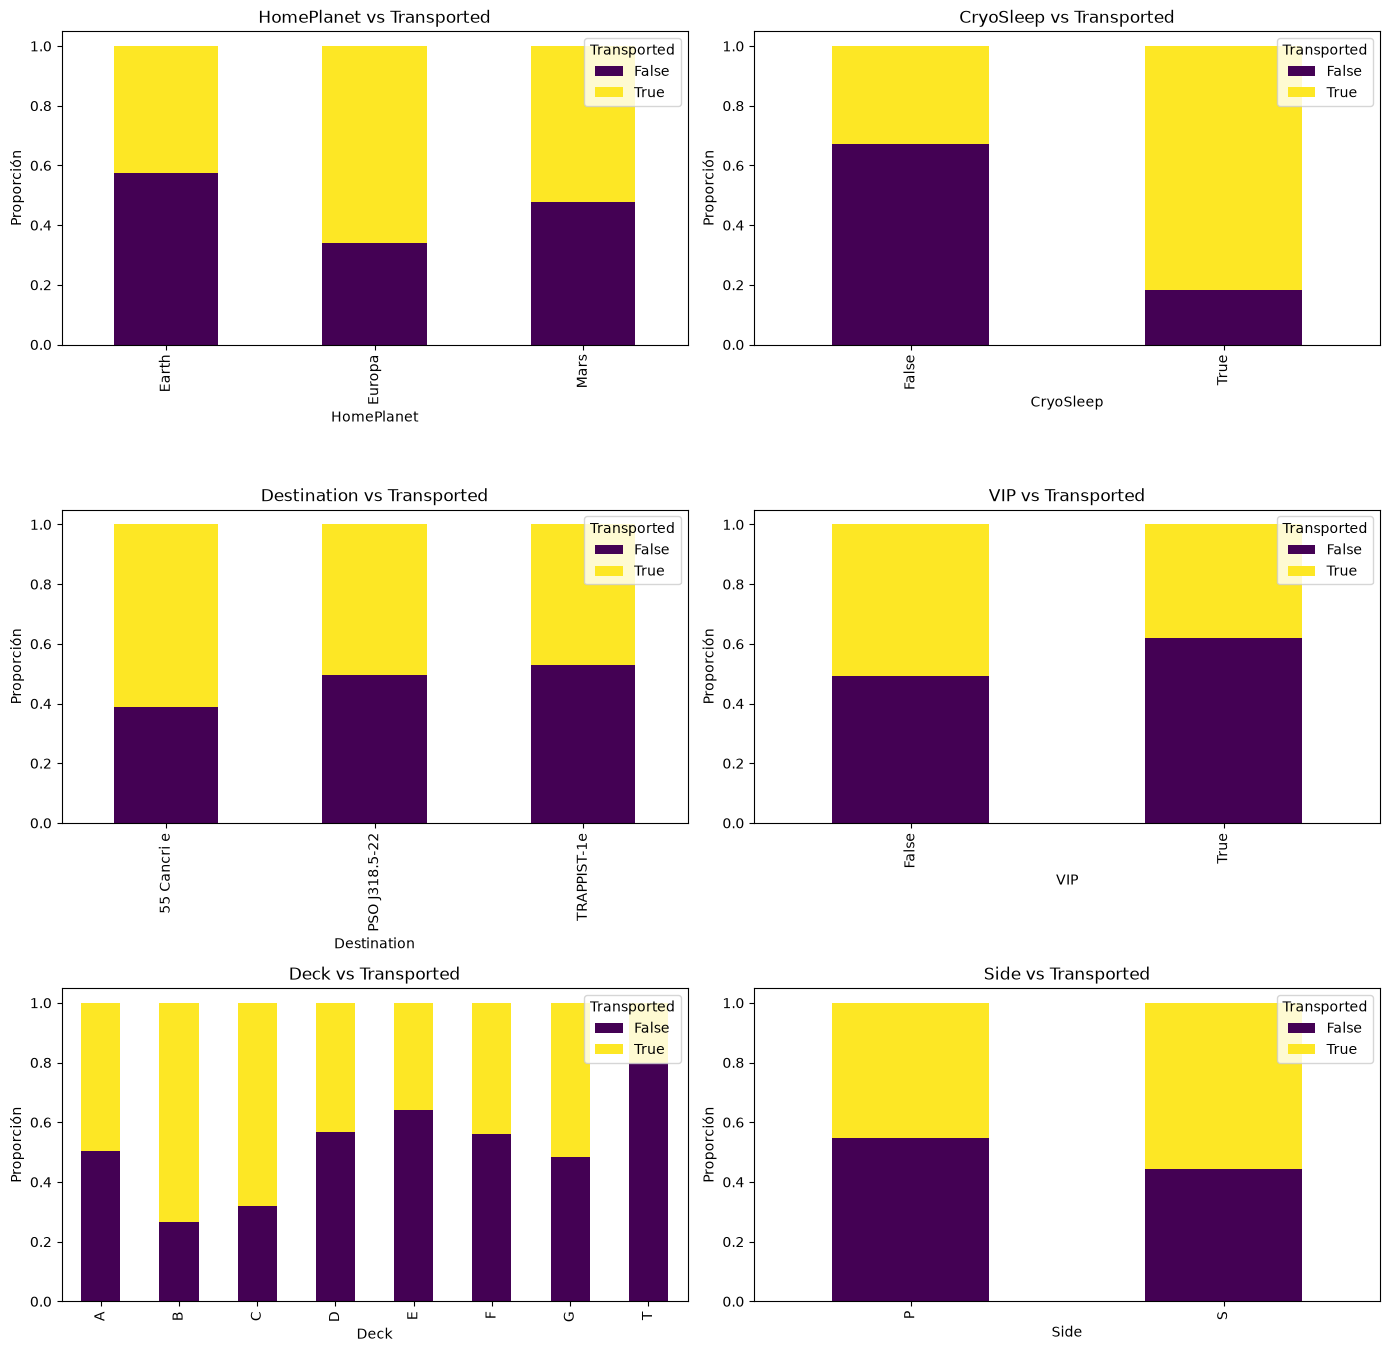

In [20]:
v_categoricas_crosstabs = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(v_categoricas_crosstabs):
    ct = pd.crosstab(train[col], train['Transported'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Transported', loc='upper right')

for j in range(len(v_categoricas_crosstabs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

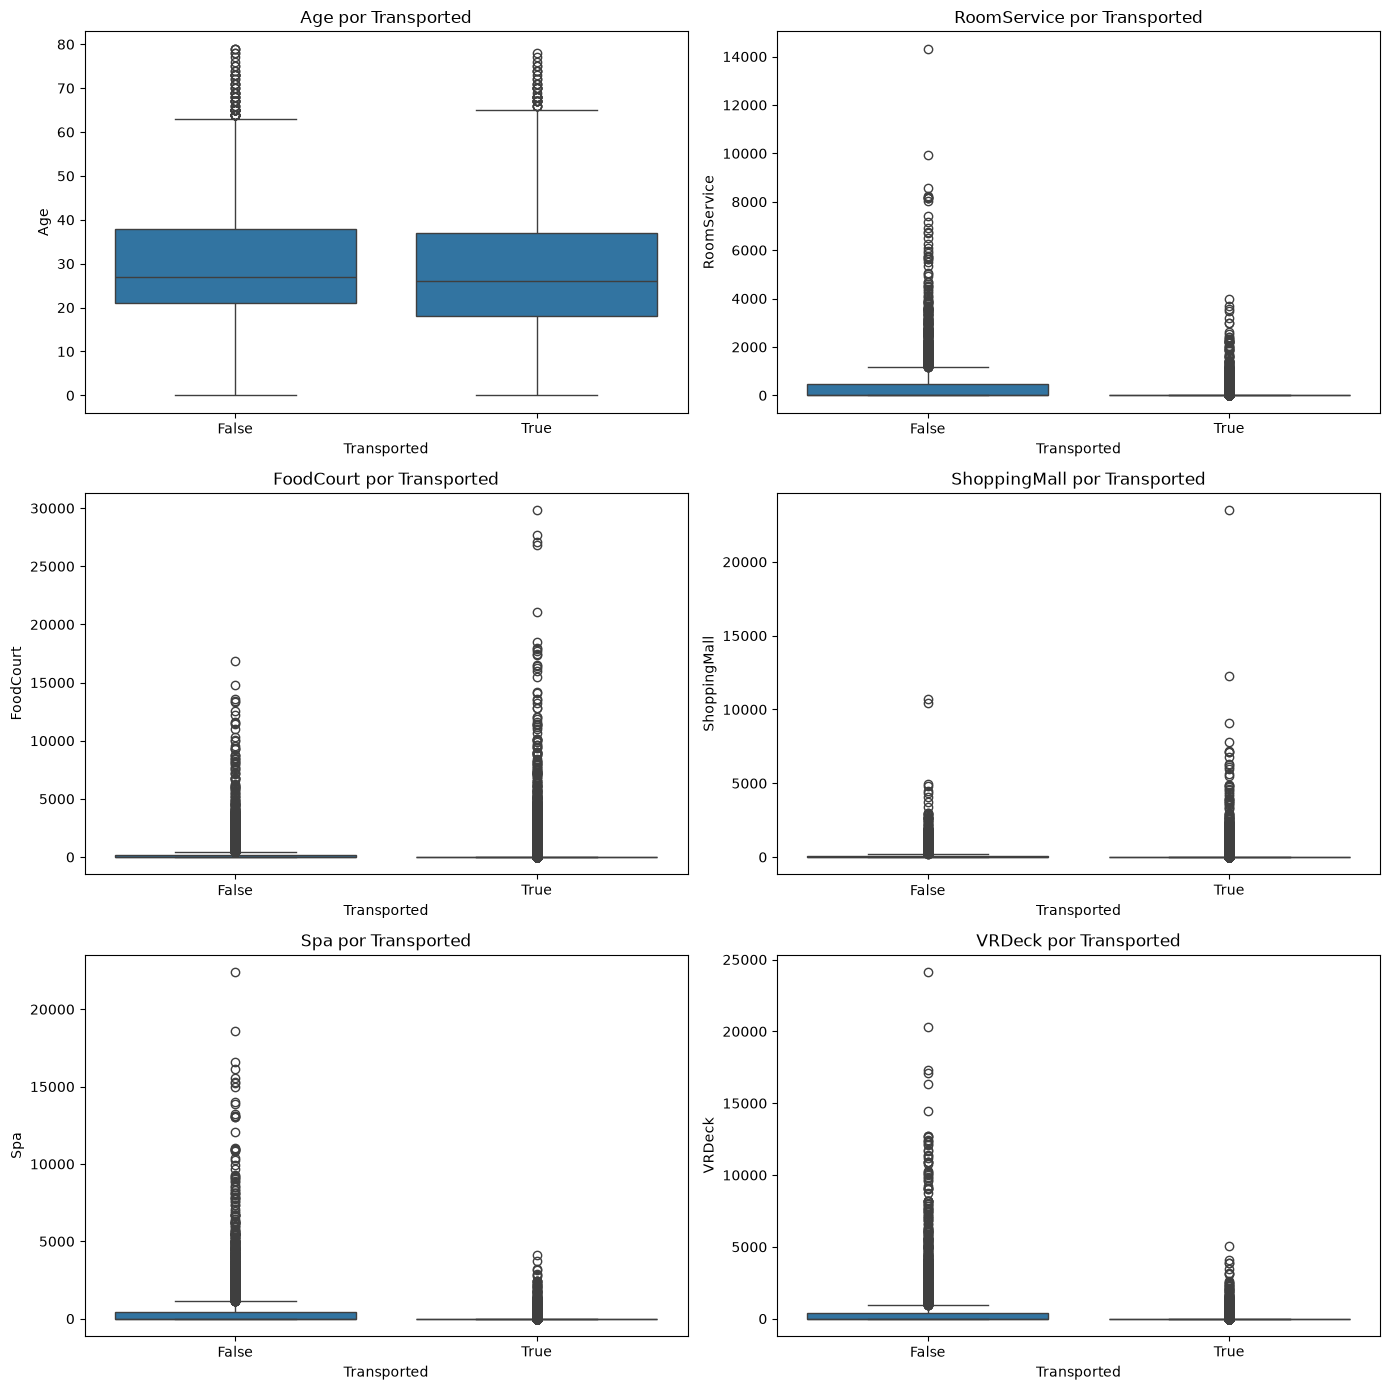

In [23]:
v_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(v_numericas):
    sns.boxplot(data=train, x='Transported', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por Transported')

plt.tight_layout()
plt.show()

## 3. Selección y descarte de variables

### 3.1 Variables incluidas en el pipeline

Listado de variables que se conservan para el modelado, con la evidencia del EDA que respalda cada inclusión (relación con el target, faltantes manejables, cardinalidad razonable, etc.).

### 3.2 Variables descartadas

Listado de variables excluidas del pipeline, justificando cada descarte con evidencia concreta: porcentaje de faltantes, desbalance extremo, ausencia de relación con el target, cardinalidad excesiva o redundancia con otra variable.

### 3.3 Evaluación de binarización para variables con desbalance extremo

Antes de descartar variables con clases muy desbalanceadas (por ejemplo, servicios de gasto a bordo), se evalúa si transformarlas en indicadores binarios (`HasPool`, `HasCabin`, etc.) preserva señal útil para el target.

## 4. Manejo de faltantes

### 4.1 Imputación de faltantes informativos

Estrategia de imputación aplicada a las variables cuyo faltante fue clasificado como informativo en el paso 2.1 (por ejemplo, imputación condicionada al valor de otra variable relacionada), con su justificación.

### 4.2 Imputación de faltantes reales

Estrategia de imputación aplicada a las variables con faltantes reales (por ejemplo, medidas de tendencia central para numéricas o moda/categoría "Unknown" para categóricas), con su justificación.

### 4.3 Resumen de estrategia de imputación por variable

Tabla o resumen que consolida, por variable, el tipo de faltante y la estrategia de imputación elegida, evitando aplicar un único criterio genérico sin argumento.

## 5. Codificación de variables categóricas

### 5.1 Codificación de variables nominales

Aplicación de codificación a variables categóricas sin orden natural, justificando la elección según cardinalidad y naturaleza de cada variable.

### 5.2 Codificación de variables ordinales

Evaluación de si alguna variable categórica presenta orden natural y, de ser así, aplicación de una codificación ordinal justificada.

### 5.3 Verificación de ausencia de columnas tipo `object`

Comprobación de que, tras la codificación, ninguna columna del dataset conserva el tipo `object`.

## 6. Transformación de variables numéricas

### 6.1 Evaluación del sesgo (skewness)

Revisión del coeficiente de asimetría de cada variable numérica para identificar cuáles presentan sesgo significativo.

### 6.2 Aplicación de transformaciones justificadas

Aplicación de una transformación (p. ej. logarítmica o `PowerTransformer`) a las variables con sesgo relevante, justificando la elección según el tipo y grado de sesgo detectado.

### 6.3 Comparación de distribuciones antes y después

Visualización comparativa (histogramas) de cada variable transformada, mostrando su distribución original frente a la distribución tras la transformación.

## 7. Escalado

### 7.1 Selección del escalador según presencia de outliers

Decisión entre `StandardScaler` y `RobustScaler` (u otra alternativa) para cada grupo de variables numéricas, en función de la presencia de outliers detectada en el paso 2.2.

### 7.2 Aplicación del escalado

Ajuste y aplicación del escalador elegido sobre las variables numéricas del dataset, con justificación de la elección.

## 8. Verificación final

### 8.1 Confirmación de ausencia de nulos

Comprobación de que el conjunto de datos procesado no contiene valores nulos.

### 8.2 Confirmación de ausencia de columnas tipo `object`

Comprobación de que todas las columnas del dataset final son de tipo numérico.

### 8.3 Shape final del dataset procesado

Reporte de la dimensión final (filas x columnas) del dataset tras todas las transformaciones.

### 8.4 Tabla resumen de decisiones

Tabla que consolida, para cada variable original: tipo de variable, tratamiento aplicado (imputación, codificación, transformación, escalado o descarte) y justificación de la decisión.

| Variable | Tipo | Tratamiento | Justificacion |
|---|---|---|---|
| PassengerId | | | |
| HomePlanet | | | |
| CryoSleep | | | |
| Cabin | | | |
| Destination | | | |
| Age | | | |
| VIP | | | |
| RoomService | | | |
| FoodCourt | | | |
| ShoppingMall | | | |
| Spa | | | |
| VRDeck | | | |
| Name | | | |
| Transported | | | |

### 8.5 Conclusiones y hallazgos

Síntesis de los principales hallazgos del análisis exploratorio y de las decisiones de preparación de datos, y su relevancia para el modelado posterior.